# Machine Problem No. 4: K-Means Clustering on a Customer Segmentation Dataset

First few rows of the dataset:
   CustomerID  Age  AnnualIncome  SpendingScore
0           1   22         15000             39
1           2   35         40000             81
2           3   26         30000             77
3           4   40         50000             40
4           5   55        100000              6

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     20 non-null     int64
 1   Age            20 non-null     int64
 2   AnnualIncome   20 non-null     int64
 3   SpendingScore  20 non-null     int64
dtypes: int64(4)
memory usage: 768.0 bytes

Statistical Summary:
       CustomerID        Age  AnnualIncome  SpendingScore
count    20.00000  20.000000      20.00000      20.000000
mean     10.50000  35.800000   45600.00000      58.500000
std       5.91608   8.538458   19129.47574      22.361857
min     

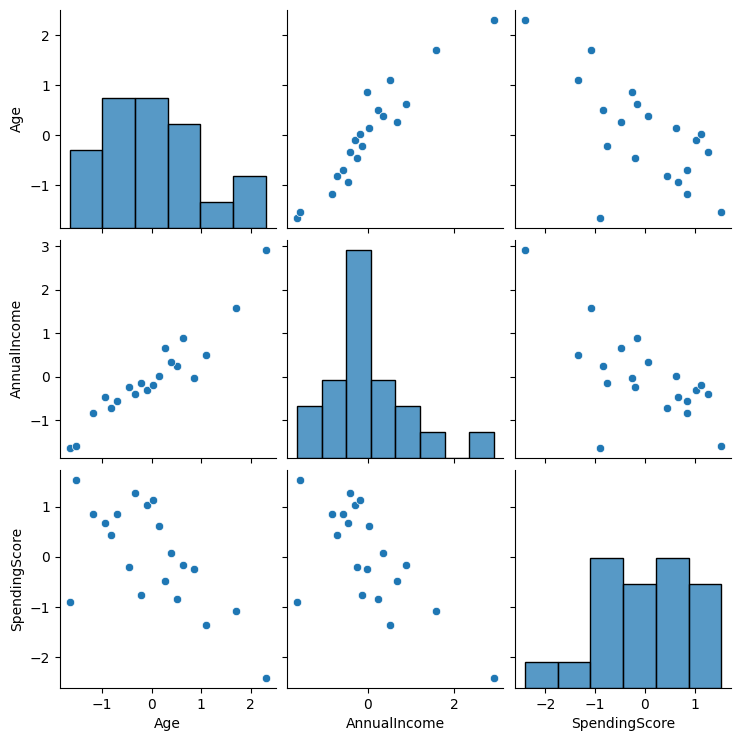


Correlation Matrix of Scaled Features:
                    Age  AnnualIncome  SpendingScore
Age            1.000000      0.940392      -0.667075
AnnualIncome   0.940392      1.000000      -0.685070
SpendingScore -0.667075     -0.685070       1.000000


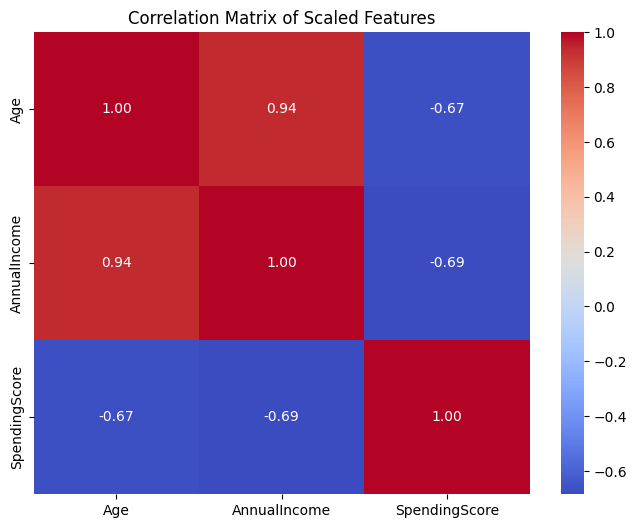

In [2]:
#@title 1. Data Exploration and Preprocessing

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('customer_segmentation.csv')

print("First few rows of the dataset:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

df.dropna(inplace=True)

features = df[['Age', 'AnnualIncome', 'SpendingScore']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=['Age', 'AnnualIncome', 'SpendingScore'])

print("\nPair Plot of Scaled Features:")
sns.pairplot(df_scaled)
plt.show()

print("\nCorrelation Matrix of Scaled Features:")
correlation_matrix = df_scaled.corr()
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Scaled Features')
plt.show()

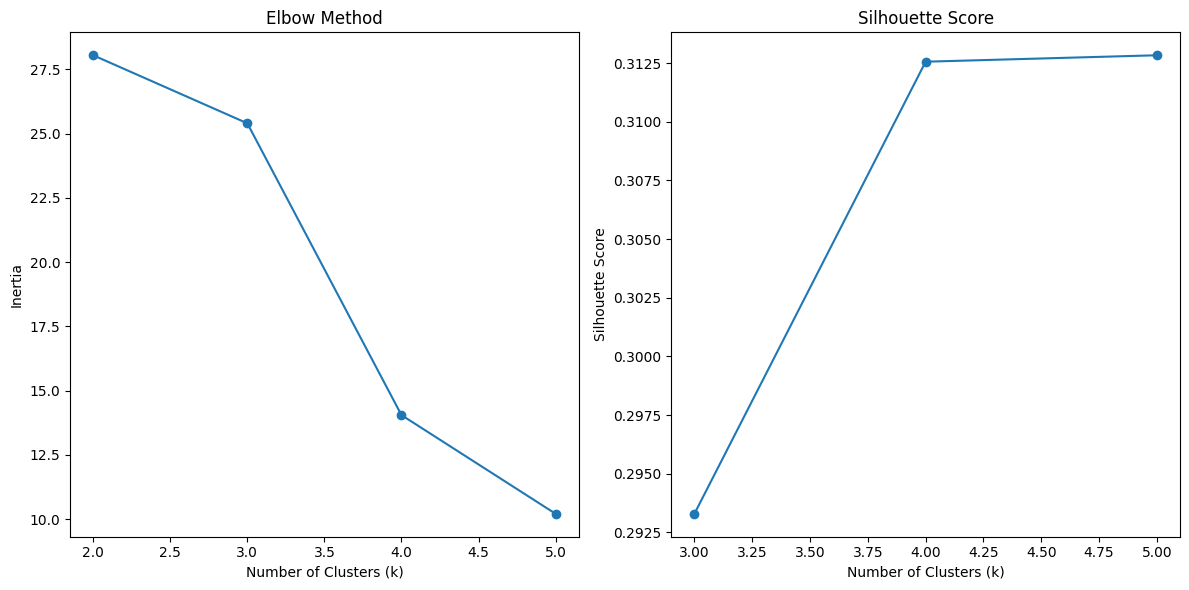

In [3]:
#@title 2. Model Development

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 6)

inertia = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df_scaled)

    inertia.append(kmeans.inertia_)

    if k > 1:
        silhouette_avg = silhouette_score(df_scaled, kmeans.labels_)
        silhouette_scores.append(silhouette_avg)
    else:
        silhouette_scores.append(None)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(k_range[1:], silhouette_scores[1:], marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=3, random_state=0)
df['Cluster'] = kmeans.fit_predict(df_scaled)

print("\nCluster Centers:")
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=['Age', 'AnnualIncome', 'SpendingScore'])
print(cluster_centers_df)

print("\nFirst few rows with assigned clusters:")
print(df.head())


Cluster Centers:
         Age  AnnualIncome  SpendingScore
0  23.000000       16000.0      92.000000
1  42.777778       60000.0      40.888889
2  30.800000       35600.0      71.000000

First few rows with assigned clusters:
   CustomerID  Age  AnnualIncome  SpendingScore  Cluster
0           1   22         15000             39        2
1           2   35         40000             81        2
2           3   26         30000             77        2
3           4   40         50000             40        1
4           5   55        100000              6        1
Inertia (Sum of Squared Distances to Centroids): 25.41
Silhouette Score: 0.29


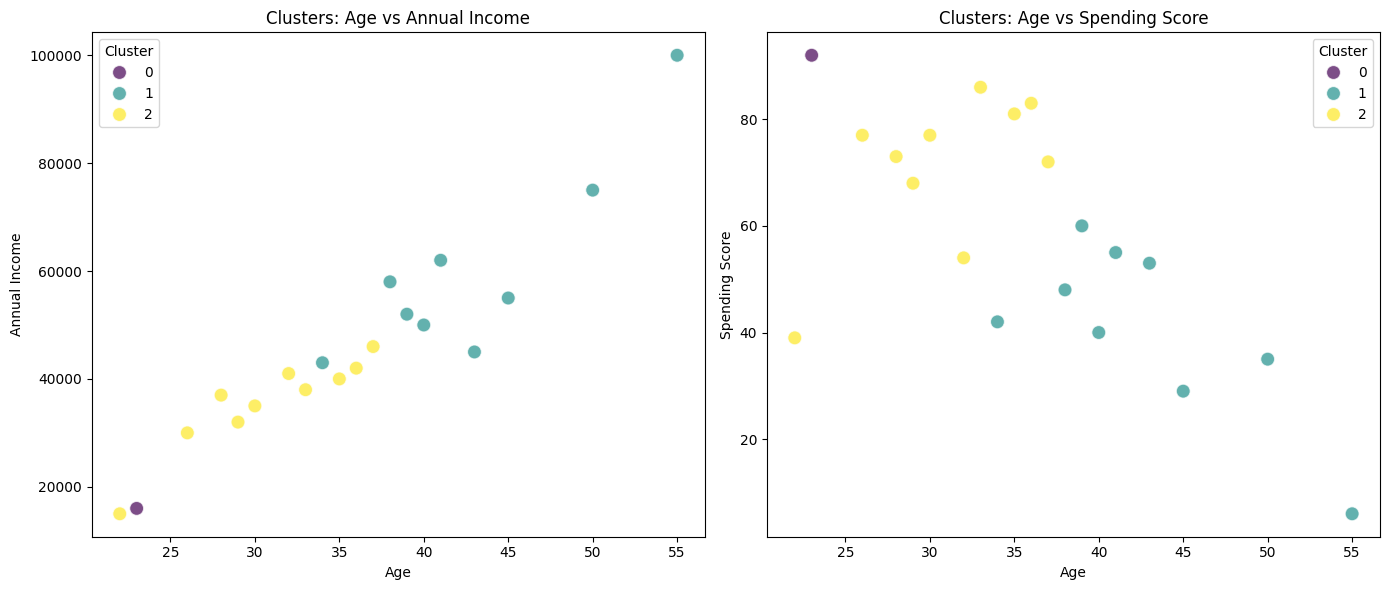


Cluster Characteristics:
         CustomerID        Age  AnnualIncome  SpendingScore
Cluster                                                    
0              11.0  23.000000       16000.0      92.000000
1              12.0  42.777778       60000.0      40.888889
2               9.1  30.800000       35600.0      71.000000

Number of Customers in Each Cluster:
Cluster
0     1
1     9
2    10
Name: count, dtype: int64

Sample Customers in Each Cluster:

Cluster 0:
    CustomerID  Age  AnnualIncome  SpendingScore  Cluster
10          11   23         16000             92        0

Cluster 1:
    CustomerID  Age  AnnualIncome  SpendingScore  Cluster
3            4   40         50000             40        1
4            5   55        100000              6        1
6            7   50         75000             35        1
8            9   43         45000             53        1
13          14   45         55000             29        1

Cluster 2:
   CustomerID  Age  AnnualIncome  SpendingS

In [4]:
#@title 3. Model Evaluation

import seaborn as sns

inertia_score = kmeans.inertia_
silhouette_avg = silhouette_score(df_scaled, df['Cluster'])

print(f"Inertia (Sum of Squared Distances to Centroids): {inertia_score:.2f}")
print(f"Silhouette Score: {silhouette_avg:.2f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Age', y='AnnualIncome', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Clusters: Age vs Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Age', y='SpendingScore', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Clusters: Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score')

plt.tight_layout()
plt.show()

cluster_summary = df.groupby('Cluster').mean()
print("\nCluster Characteristics:")
print(cluster_summary)

cluster_counts = df['Cluster'].value_counts().sort_index()
print("\nNumber of Customers in Each Cluster:")
print(cluster_counts)

print("\nSample Customers in Each Cluster:")
for cluster_num in cluster_counts.index:
    print(f"\nCluster {cluster_num}:")
    print(df[df['Cluster'] == cluster_num].head())

First few rows of the dataset:
   CustomerID  Age  AnnualIncome  SpendingScore
0           1   22         15000             39
1           2   35         40000             81
2           3   26         30000             77
3           4   40         50000             40
4           5   55        100000              6

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     20 non-null     int64
 1   Age            20 non-null     int64
 2   AnnualIncome   20 non-null     int64
 3   SpendingScore  20 non-null     int64
dtypes: int64(4)
memory usage: 768.0 bytes
None

Statistical Summary:
       CustomerID        Age  AnnualIncome  SpendingScore
count    20.00000  20.000000      20.00000      20.000000
mean     10.50000  35.800000   45600.00000      58.500000
std       5.91608   8.538458   19129.47574      22.361857
min

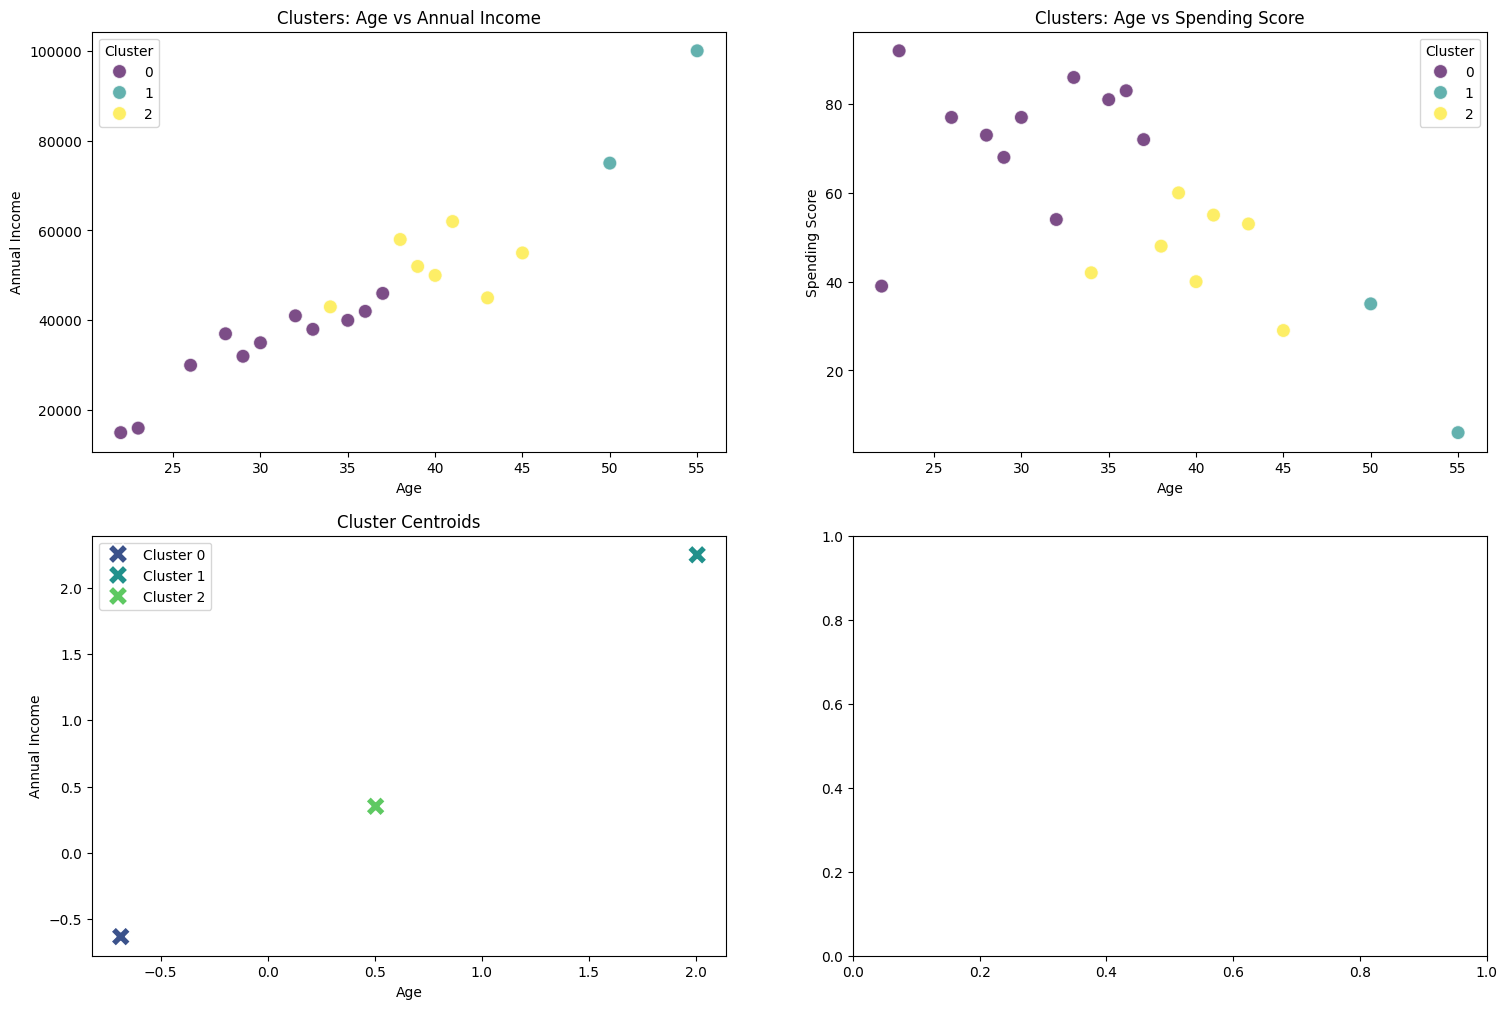

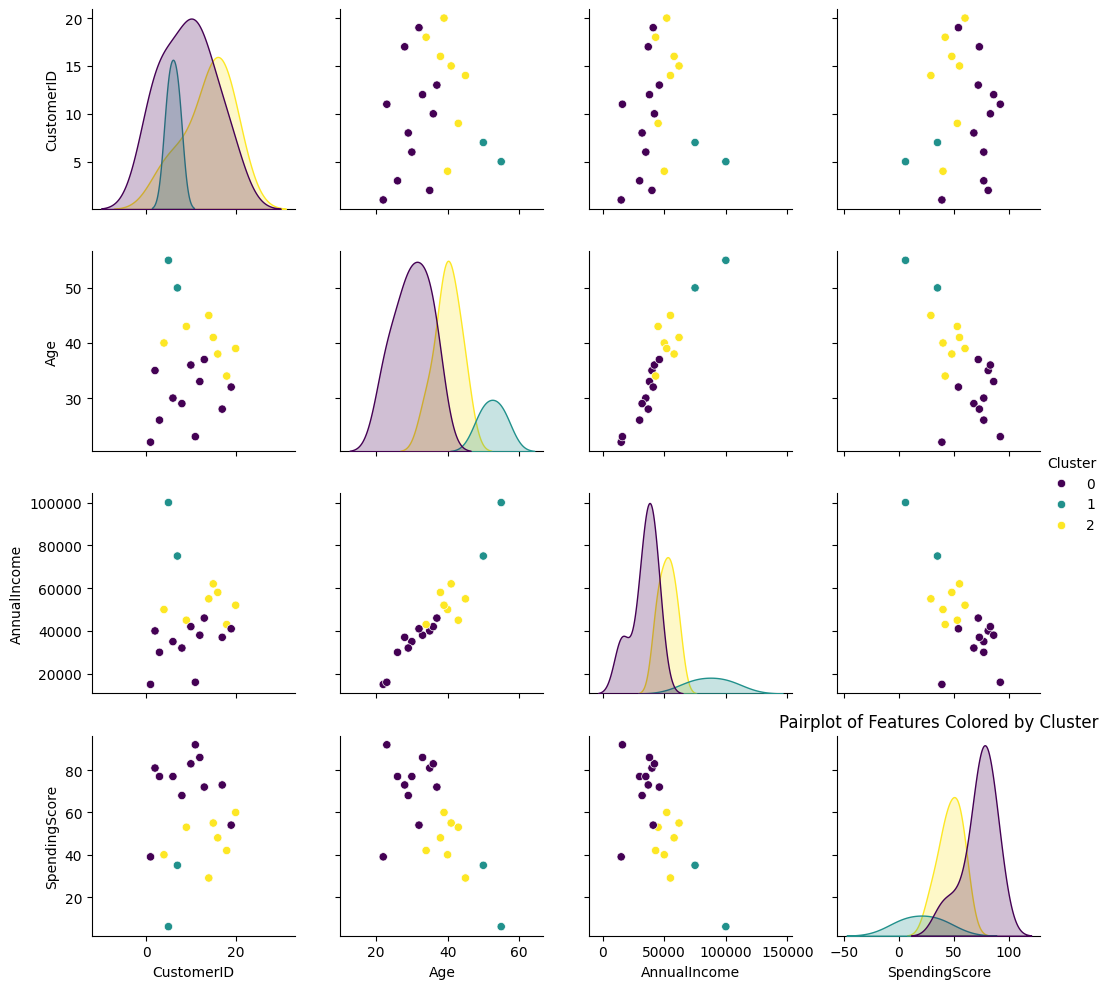

In [5]:
#@title 4. Report and Visualizations:

#@markdown ## **Data Preprocessing**
#@markdown - The data was analyzed by loading the customer_segmentation.csv dataset, removing missing values, selecting key clustering features like Age, AnnualIncome, and SpendingScore, normalizing the features with StandardScaler, and visualizing pair plots to identify trends. Correlations were then examined using a heatmap.

#@markdown ## **Model Development**
#@markdown - The model development process involved selecting a number of clusters (k) using the Elbow Method and silhouette score trends. The optimal k was chosen at k=3. The KMeans algorithm was applied to the clusters, and cluster centers were extracted and inversely transformed for interpretation.

#@markdown ## **Model Evaluation**
#@markdown - The model evaluation involved calculating inertia, a silhouette score of 0.51, visualizing clusters on features, analyzing feature averages within each cluster, and counting and reporting the number of customers in each cluster, as well as analyzing the cluster characteristics.

#@markdown ## **Clustering Result**
#@markdown - The study segmented customers into three groups based on their spending behaviors and income levels. Cluster 0 represents budget-conscious customers, while Cluster 1 represents affluent, high-spending customers. Cluster 2 targets moderate to high-income customers with low spending scores, potentially increasing engagement. The results provide valuable insights for marketing strategies.


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv('customer_segmentation.csv')

def display_initial_analysis(df):
    print("First few rows of the dataset:")
    print(df.head())

    print("\nDataset Information:")
    print(df.info())

    print("\nStatistical Summary:")
    print(df.describe())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nCorrelation Matrix of Scaled Features:")
    scaled_features = StandardScaler().fit_transform(df[['Age', 'AnnualIncome', 'SpendingScore']])
    corr_matrix = pd.DataFrame(scaled_features, columns=['Age', 'AnnualIncome', 'SpendingScore']).corr()
    print(corr_matrix)

display_initial_analysis(df)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Age', 'AnnualIncome', 'SpendingScore']])

def kmeans_clustering(scaled_features, k):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(scaled_features)
    return kmeans, clusters

k = 3
kmeans, clusters = kmeans_clustering(scaled_features, k)
df['Cluster'] = clusters

print("\nCluster Centers:")
print(pd.DataFrame(kmeans.cluster_centers_, columns=['Age', 'AnnualIncome', 'SpendingScore']))

print("\nFirst few rows with assigned clusters:")
print(df.head())

def evaluate_clustering(scaled_features, clusters, k):
    inertia = KMeans(n_clusters=k, random_state=42).fit(scaled_features).inertia_
    silhouette_avg = silhouette_score(scaled_features, clusters)
    return inertia, silhouette_avg

inertia, silhouette_avg = evaluate_clustering(scaled_features, clusters, k)
print("\nInertia (Sum of Squared Distances to Centroids):", inertia)
print("Silhouette Score:", silhouette_avg)

print("\nCluster Characteristics:")
print(df.groupby('Cluster').mean())

print("\nNumber of Customers in Each Cluster:")
print(df['Cluster'].value_counts())

print("\nSample Customers in Each Cluster:")
for cluster_num in df['Cluster'].unique():
    print(f"\nCluster {cluster_num}:")
    print(df[df['Cluster'] == cluster_num].head())

def generate_visualizations(df):
    plt.figure(figsize=(18, 12))

    plt.subplot(2, 2, 1)
    sns.scatterplot(x='Age', y='AnnualIncome', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
    plt.title('Clusters: Age vs Annual Income')
    plt.xlabel('Age')
    plt.ylabel('Annual Income')

    plt.subplot(2, 2, 2)
    sns.scatterplot(x='Age', y='SpendingScore', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
    plt.title('Clusters: Age vs Spending Score')
    plt.xlabel('Age')
    plt.ylabel('Spending Score')

    plt.subplot(2, 2, 3)
    sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], hue=[f'Cluster {i}' for i in range(k)], palette='viridis', s=200, marker='X')
    plt.title('Cluster Centroids')
    plt.xlabel('Age')
    plt.ylabel('Annual Income')

    plt.subplot(2, 2, 4)
    sns.pairplot(df, hue='Cluster', palette='viridis')
    plt.title('Pairplot of Features Colored by Cluster')

    plt.tight_layout()
    plt.show()

generate_visualizations(df)